<a href="https://colab.research.google.com/github/14-vaibhav/ML_CWS/blob/main/food_processing_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# =========================================
# STEP 1: Upload multiple CSV files
# =========================================
from google.colab import files
uploaded = files.upload()

Saving FOOD-DATA-GROUP3.csv to FOOD-DATA-GROUP3 (1).csv
Saving FOOD-DATA-GROUP2.csv to FOOD-DATA-GROUP2.csv
Saving FOOD-DATA-GROUP1.csv to FOOD-DATA-GROUP1.csv


In [ ]:
# =========================================
# STEP 2: Imports
# =========================================
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.svm import SVR

from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

In [ ]:
# =========================================
# STEP 3: See uploaded file names
# =========================================
file_names = list(uploaded.keys())
print("Uploaded files:")
for i, f in enumerate(file_names):
    print(f"{i+1}. {f}")

Uploaded files:
1. FOOD-DATA-GROUP3 (1).csv
2. FOOD-DATA-GROUP2.csv
3. FOOD-DATA-GROUP1.csv


In [ ]:
import io

all_dfs = []
for file_name in file_names:
    # Read the content of the uploaded file
    file_content = uploaded[file_name]
    # Use io.StringIO to treat the byte string as a file
    df = pd.read_csv(io.StringIO(file_content.decode('utf-8')))
    all_dfs.append(df)

# Concatenate all dataframes into a single one
combined_df = pd.concat(all_dfs, ignore_index=True)

# Display the first few rows of the combined dataframe
print("Combined DataFrame head:")
display(combined_df.head())

print("\nCombined DataFrame info:")
combined_df.info()

Combined DataFrame head:


,Unnamed: 0.1,Unnamed: 0,food,Caloric Value,Fat,Saturated Fats,Monounsaturated Fats,Polyunsaturated Fats,Carbohydrates,Sugars,...,Calcium,Copper,Iron,Magnesium,Manganese,Phosphorus,Potassium,Selenium,Zinc,Nutrition Density
0,0,0,nectarine,66,0.500,0.066,0.100,0.200,15.8,11.8,...,0.081,9.000,0.100,0.4,13.500,0.002,39.0,301.500,0.000,20.735
1,1,1,kiwifruit gold,51,0.200,0.008,0.099,0.051,12.8,10.0,...,13.800,0.100,0.200,9.7,0.072,20.300,255.2,0.003,0.077,159.686
2,2,2,prickly pear raw,8,0.072,0.000,0.000,0.000,1.9,0.2,...,34.200,0.051,0.021,13.1,0.100,2.100,24.7,0.023,0.073,39.263
3,3,3,pineapple,45,0.100,0.074,0.001,0.087,11.8,8.9,...,0.061,11.700,0.091,0.3,10.800,0.800,7.2,98.100,0.061,13.970
4,4,4,rowan,253,4.600,0.600,0.000,0.000,54.5,32.1,...,34.200,2.400,5.000,73.0,0.400,118.600,298.7,0.000,1.000,176.400



Combined DataFrame info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1441 entries, 0 to 1440
Data columns (total 37 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Unnamed: 0.1          1441 non-null   int64  
 1   Unnamed: 0            1441 non-null   int64  
 2   food                  1441 non-null   object 
 3   Caloric Value         1441 non-null   int64  
 4   Fat                   1441 non-null   float64
 5   Saturated Fats        1441 non-null   float64
 6   Monounsaturated Fats  1441 non-null   float64
 7   Polyunsaturated Fats  1441 non-null   float64
 8   Carbohydrates         1441 non-null   float64
 9   Sugars                1441 non-null   float64
 10  Protein               1441 non-null   float64
 11  Dietary Fiber         1441 non-null   float64
 12  Cholesterol           1441 non-null   float64
 13  Sodium                1441 non-null   float64
 14  Water                 1441 non-null   float64


In [ ]:
# Drop the 'Unnamed' columns as they seem to be redundant indices
combined_df = combined_df.drop(columns=['Unnamed: 0.1', 'Unnamed: 0'])

# Display the updated DataFrame info to confirm the columns are dropped
print("DataFrame after dropping 'Unnamed' columns:")
combined_df.info()

# Define features (X) and target (y)
X = combined_df.drop('Nutrition Density', axis=1)  # Features are all columns except 'Nutrition Density'
y = combined_df['Nutrition Density']  # Target variable

# Display the first few rows of X and y
print("\nFeatures (X) head:")
display(X.head())

print("\nTarget (y) head:")
display(y.head())

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"\nTraining features shape: {X_train.shape}")
print(f"Testing features shape: {X_test.shape}")
print(f"Training target shape: {y_train.shape}")
print(f"Testing target shape: {y_test.shape}")

DataFrame after dropping 'Unnamed' columns:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1441 entries, 0 to 1440
Data columns (total 35 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   food                  1441 non-null   object 
 1   Caloric Value         1441 non-null   int64  
 2   Fat                   1441 non-null   float64
 3   Saturated Fats        1441 non-null   float64
 4   Monounsaturated Fats  1441 non-null   float64
 5   Polyunsaturated Fats  1441 non-null   float64
 6   Carbohydrates         1441 non-null   float64
 7   Sugars                1441 non-null   float64
 8   Protein               1441 non-null   float64
 9   Dietary Fiber         1441 non-null   float64
 10  Cholesterol           1441 non-null   float64
 11  Sodium                1441 non-null   float64
 12  Water                 1441 non-null   float64
 13  Vitamin A             1441 non-null   float64
 14  Vitamin B1            1441 n

,food,Caloric Value,Fat,Saturated Fats,Monounsaturated Fats,Polyunsaturated Fats,Carbohydrates,Sugars,Protein,Dietary Fiber,...,Vitamin K,Calcium,Copper,Iron,Magnesium,Manganese,Phosphorus,Potassium,Selenium,Zinc
0,nectarine,66,0.500,0.066,0.100,0.200,15.8,11.8,1.600,2.6,...,1.200,0.081,9.000,0.100,0.4,13.500,0.002,39.0,301.500,0.000
1,kiwifruit gold,51,0.200,0.008,0.099,0.051,12.8,10.0,0.800,1.1,...,0.074,13.800,0.100,0.200,9.7,0.072,20.300,255.2,0.003,0.077
2,prickly pear raw,8,0.072,0.000,0.000,0.000,1.9,0.2,0.001,1.0,...,0.018,34.200,0.051,0.021,13.1,0.100,2.100,24.7,0.023,0.073
3,pineapple,45,0.100,0.074,0.001,0.087,11.8,8.9,0.500,1.3,...,0.078,0.061,11.700,0.091,0.3,10.800,0.800,7.2,98.100,0.061
4,rowan,253,4.600,0.600,0.000,0.000,54.5,32.1,5.200,14.1,...,0.000,34.200,2.400,5.000,73.0,0.400,118.600,298.7,0.000,1.000



Target (y) head:


,Nutrition Density
0,20.735
1,159.686
2,39.263
3,13.970
4,176.400



Training features shape: (1152, 34)
Testing features shape: (289, 34)
Training target shape: (1152,)
Testing target shape: (289,)


In [ ]:
# Identify categorical and numerical features
categorical_features = ['food']
numerical_features = X.select_dtypes(include=np.number).columns.tolist()

# Create preprocessing pipelines for numerical and categorical features
numerical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='mean')),
    ('scaler', StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

# Create a column transformer to apply different transformations to different columns
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numerical_transformer, numerical_features),
        ('cat', categorical_transformer, categorical_features)
    ])

# Define the models
models = {
    'Linear Regression': LinearRegression(),
    'Random Forest Regressor': RandomForestRegressor(random_state=42),
    'Support Vector Regressor': SVR()
}

# Train and evaluate each model
results = {}
for name, model in models.items():
    # Create a pipeline with preprocessing and the model
    pipeline = Pipeline(steps=[('preprocessor', preprocessor),
                               ('regressor', model)])

    # Train the model
    pipeline.fit(X_train, y_train)

    # Make predictions
    y_pred = pipeline.predict(X_test)

    # Evaluate the model
    mse = mean_squared_error(y_test, y_pred)
    mae = mean_absolute_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)

    results[name] = {'MSE': mse, 'MAE': mae, 'R2': r2}

    print(f"\n--- {name} ---")
    print(f"Mean Squared Error (MSE): {mse:.2f}")
    print(f"Mean Absolute Error (MAE): {mae:.2f}")
    print(f"R-squared (R2): {r2:.2f}")

print("\n--- Model Comparison ---")
for name, metrics in results.items():
    print(f"{name}: R2={metrics['R2']:.2f}, MSE={metrics['MSE']:.2f}, MAE={metrics['MAE']:.2f}")


--- Linear Regression ---
Mean Squared Error (MSE): 0.35
Mean Absolute Error (MAE): 0.28
R-squared (R2): 1.00

--- Random Forest Regressor ---
Mean Squared Error (MSE): 3706.24
Mean Absolute Error (MAE): 17.06
R-squared (R2): 0.91

--- Support Vector Regressor ---
Mean Squared Error (MSE): 33271.82
Mean Absolute Error (MAE): 74.64
R-squared (R2): 0.18

--- Model Comparison ---
Linear Regression: R2=1.00, MSE=0.35, MAE=0.28
Random Forest Regressor: R2=0.91, MSE=3706.24, MAE=17.06
Support Vector Regressor: R2=0.18, MSE=33271.82, MAE=74.64


### Scatter Plot: Protein vs. Nutrition Density

This plot visualizes the relationship between the 'Protein' content of food items and their 'Nutrition Density'.

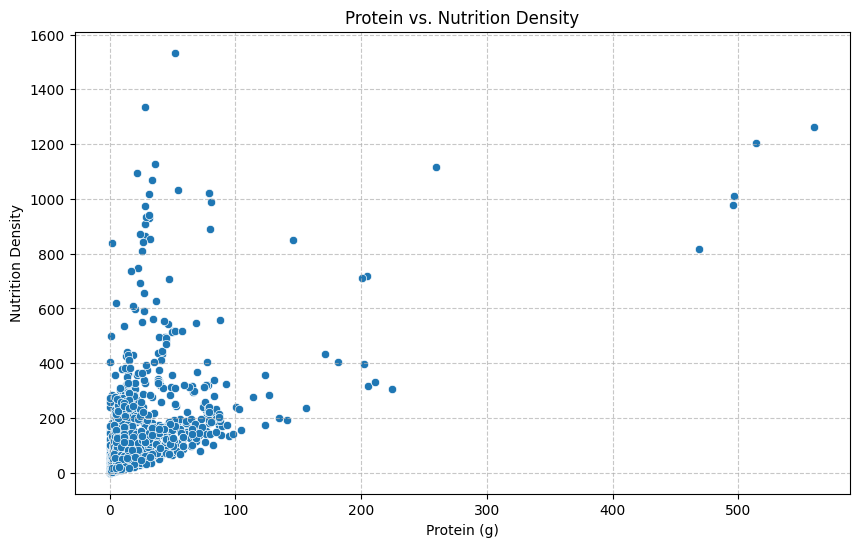

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.scatterplot(x='Protein', y='Nutrition Density', data=combined_df)
plt.title('Protein vs. Nutrition Density')
plt.xlabel('Protein (g)')
plt.ylabel('Nutrition Density')
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

### Heatmap: Correlations with Nutrition Density

This heatmap visualizes the Pearson correlation coefficients between each numerical nutrient and the 'Nutrition Density'. A value close to 1 indicates a strong positive correlation, a value close to -1 indicates a strong negative correlation, and a value close to 0 indicates a weak or no linear correlation. This can help identify key nutrients that influence the overall nutrition density.

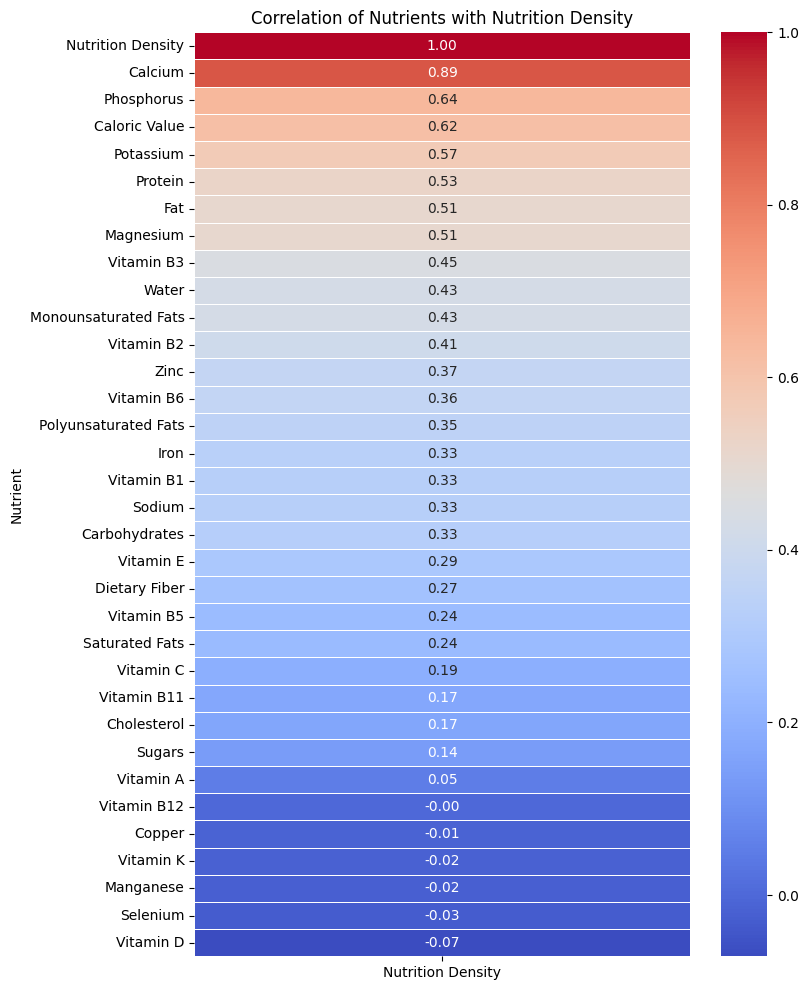

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Select only numerical columns for correlation calculation
# Exclude 'food' as it's categorical and 'Nutrition Density' as it's the target
numerical_cols = combined_df.select_dtypes(include=np.number).columns.tolist()

# Ensure 'Nutrition Density' is in the list for correlation calculation if not already included
# and remove it if it's the only column to avoid issues with correlation matrix
if 'Nutrition Density' not in numerical_cols:
    numerical_cols.append('Nutrition Density')

# Calculate the correlation matrix specifically for 'Nutrition Density' with other numerical features
correlation_with_target = combined_df[numerical_cols].corr()[['Nutrition Density']].sort_values(by='Nutrition Density', ascending=False)

plt.figure(figsize=(8, 12))
sns.heatmap(correlation_with_target, annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5)
plt.title('Correlation of Nutrients with Nutrition Density')
plt.ylabel('Nutrient')
plt.show()

### Model Performance Comparison Graphs

These graphs compare the R-squared (R2), Mean Squared Error (MSE), and Mean Absolute Error (MAE) across the Linear Regression, Random Forest Regressor, and Support Vector Regressor models. A higher R2 indicates a better fit, while lower MSE and MAE values indicate better predictive accuracy.

/tmp/ipykernel_13608/2782268785.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(ax=axes[0], x='Model', y='R2', data=results_df, palette='viridis')
/tmp/ipykernel_13608/2782268785.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(ax=axes[1], x='Model', y='MSE', data=results_df, palette='magma')
/tmp/ipykernel_13608/2782268785.py:24: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(ax=axes[2], x='Model', y='MAE', data=results_df, palette='plasma')


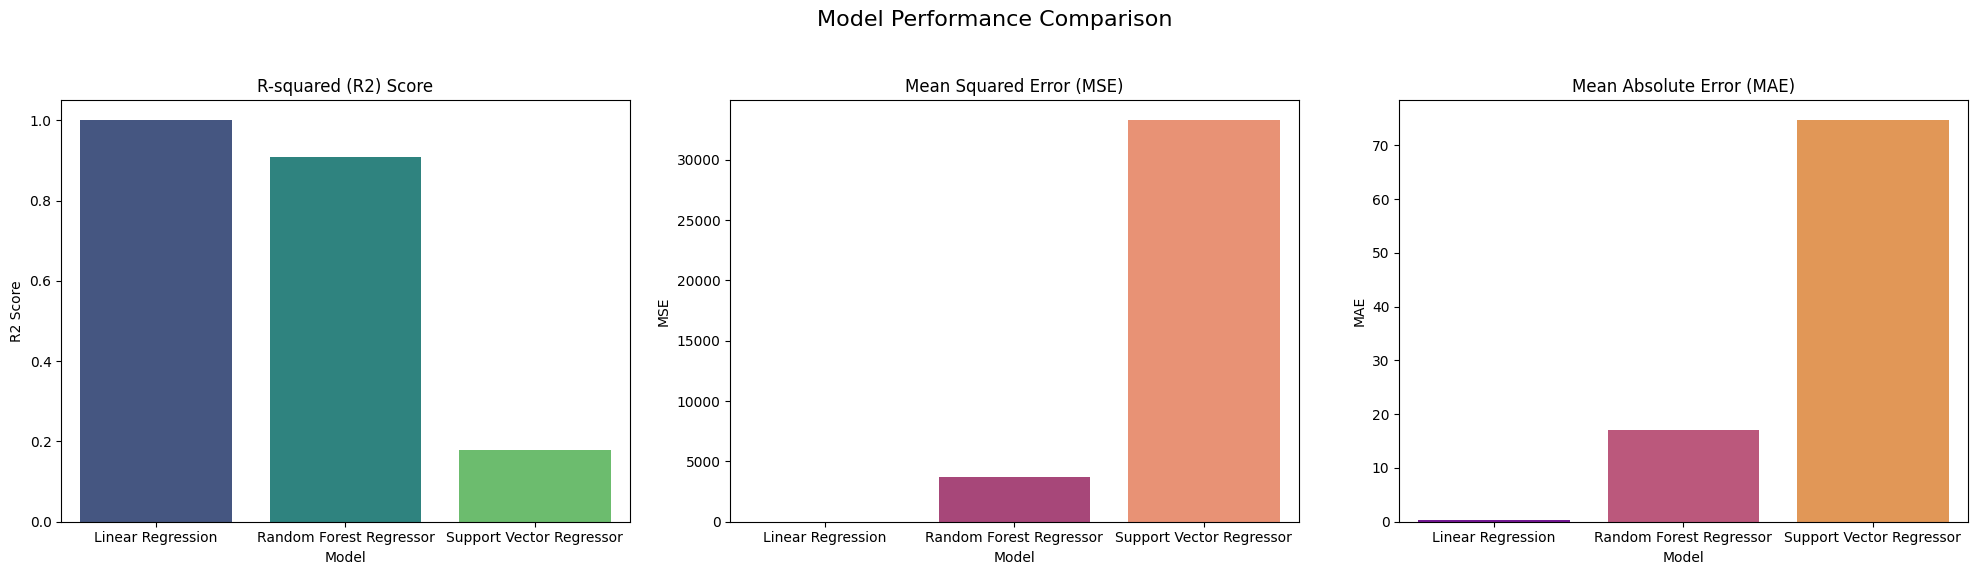

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Convert results dictionary to a DataFrame for easier plotting
results_df = pd.DataFrame(results).T.reset_index()
results_df.columns = ['Model', 'MSE', 'MAE', 'R2']

fig, axes = plt.subplots(1, 3, figsize=(20, 6))
fig.suptitle('Model Performance Comparison', fontsize=16)

# Plot R2 Scores
sns.barplot(ax=axes[0], x='Model', y='R2', data=results_df, palette='viridis')
axes[0].set_title('R-squared (R2) Score')
axes[0].set_ylabel('R2 Score')
axes[0].set_ylim(0, 1.05)

# Plot MSE Scores
sns.barplot(ax=axes[1], x='Model', y='MSE', data=results_df, palette='magma')
axes[1].set_title('Mean Squared Error (MSE)')
axes[1].set_ylabel('MSE')

# Plot MAE Scores
sns.barplot(ax=axes[2], x='Model', y='MAE', data=results_df, palette='plasma')
axes[2].set_title('Mean Absolute Error (MAE)')
axes[2].set_ylabel('MAE')

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()